In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import numpy as np
from sklearn.manifold import TSNE
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
# 数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.MNIST("./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST("./data", train=False, transform=transform, download=True)
train_data = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_data = DataLoader(train_dataset, batch_size=32, shuffle=True)



In [3]:
class res_block(nn.Module):
    def __init__(self,channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(channels,channels,kernel_size=3,padding=1,stride=1),
            nn.ReLU(),
            nn.Conv2d(channels,channels,kernel_size=3,padding=1,stride=1)
        )
     
    def forward(self, x):
        return self.block(x) + x

In [ ]:

class Encoder(nn.Module):
    def __init__(self, in_channels, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size 
        self.cov1 = nn.Conv2d(in_channels=in_channels, out_channels=32,
                              kernel_size=4, padding=1, stride=2)
        self.cov2 = nn.Conv2d(in_channels=32, out_channels=64,
                              kernel_size=4, padding=1, stride=2)
        self.resblock = res_block(64)
        self.linear_mu = nn.Linear(64*7*7, hidden_size)
        self.linear_logvar = nn.Linear(64*7*7, hidden_size)  
        
    def forward(self, x):
        x_block = self.resblock(self.cov2(self.cov1(x)))# 得到的应该是 32,64,7,7
        x_block_reshaped = x_block.reshape(x.shape[0],-1)
        
        mu = self.linear_mu(x_block_reshaped)
        logvar = self.linear_logvar(x_block_reshaped)
        logvar = torch.clamp(logvar, -10, 2)  # 限制范围，防止exp爆炸
        
        return mu, logvar

In [ ]:
class Decoder(nn.Module):
    def __init__(self, out_channels, hidden_size):
        super().__init__()
        self.resblock = res_block(64)
        
        # 第一次上采样块: 7x7 -> 14x14
        self.upsample1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv1_1 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.relu1_1 = nn.ReLU()
        self.conv1_2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.relu1_2 = nn.ReLU()
        
        # 第二次上采样块: 14x14 -> 28x28
        self.upsample2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv2_1 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.relu2_1 = nn.ReLU()
        self.conv2_2 = nn.Conv2d(16, out_channels, kernel_size=3, padding=1)
        
        self.linear1 = nn.Linear(hidden_size, 64*7*7)
        
    def forward(self, x):
        block_x = self.linear1(x).reshape(x.shape[0], 64, 7, 7)
        x = self.resblock(block_x)
        
        # 第一次上采样: 7x7 -> 14x14
        x = self.upsample1(x)
        x = self.relu1_1(self.conv1_1(x))
        x = self.relu1_2(self.conv1_2(x))
        
        # 第二次上采样: 14x14 -> 28x28
        x = self.upsample2(x)
        x = self.relu2_1(self.conv2_1(x))
        output = self.conv2_2(x)  # logits
        
        return output
        

Epoch 1/100 | β=1.0000
  Loss: 135.7637 | Recon: 121.3419 | KL: 14.4218
Epoch 2/100 | β=1.0000
  Loss: 114.1899 | Recon: 98.0990 | KL: 16.0908
Epoch 3/100 | β=1.0000
  Loss: 110.8943 | Recon: 94.4396 | KL: 16.4548
Epoch 4/100 | β=1.0000
  Loss: 109.0037 | Recon: 92.3870 | KL: 16.6168
Epoch 5/100 | β=1.0000
  Loss: 107.8452 | Recon: 91.1153 | KL: 16.7298
Epoch 6/100 | β=1.0000
  Loss: 106.9017 | Recon: 90.0721 | KL: 16.8296
Epoch 7/100 | β=1.0000
  Loss: 106.1821 | Recon: 89.2871 | KL: 16.8951
Epoch 8/100 | β=1.0000
  Loss: 105.5236 | Recon: 88.5845 | KL: 16.9390
Epoch 9/100 | β=1.0000
  Loss: 105.0100 | Recon: 88.0204 | KL: 16.9896
Epoch 10/100 | β=1.0000
  Loss: 104.5331 | Recon: 87.5020 | KL: 17.0310
Epoch 11/100 | β=1.0000
  Loss: 104.1825 | Recon: 87.1241 | KL: 17.0584
Epoch 12/100 | β=1.0000
  Loss: 103.7732 | Recon: 86.6859 | KL: 17.0873
Epoch 13/100 | β=1.0000
  Loss: 103.4436 | Recon: 86.3293 | KL: 17.1143
Epoch 14/100 | β=1.0000
  Loss: 103.1875 | Recon: 86.0295 | KL: 17.1580


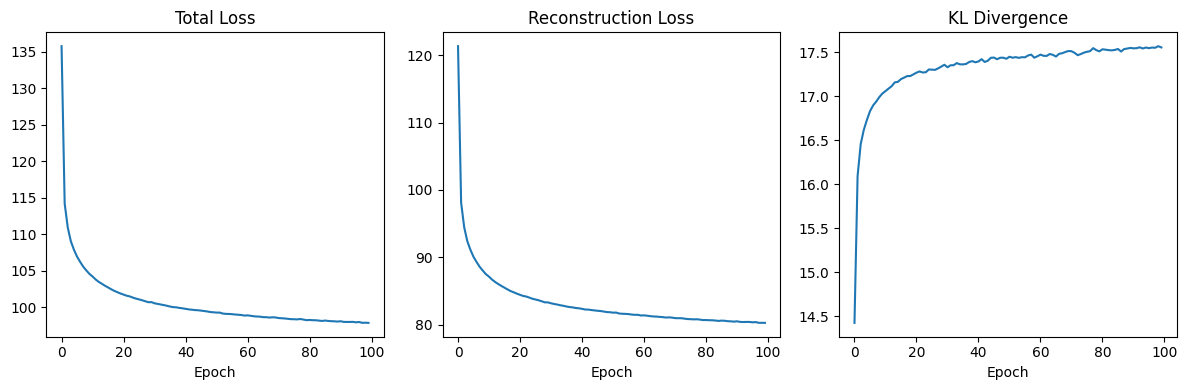

In [ ]:
epoch = 100  
lr = 0.0005 
batch_size = 32
oral_size = 28
hidden_size = 8  # 从2维提升到8维，平衡清晰度和正则化
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    
encoder = Encoder(1, hidden_size).to(device)
decoder = Decoder(1, hidden_size).to(device)

optim = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()),lr=lr)

beta = 1   

losses = []
recon_losses = []
kl_losses = []

for e in range(epoch):

    print(f"Epoch {e+1}/{epoch} | β={beta:.4f}")
    epoch_loss = 0 
    epoch_recon = 0
    epoch_kl = 0
    for batch_id ,(batch_data, batch_target_y) in enumerate(train_data):
        current_batch_size = batch_data.shape[0]
        batch_data = batch_data.to(device)
        mu, logvar = encoder(batch_data)
        # 重参数化
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
     
        pre_x = decoder(z)
        # 重构损失
        recon_loss = nn.functional.binary_cross_entropy_with_logits(pre_x, batch_data, reduction='sum') / current_batch_size
        
        # KL散度
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / current_batch_size
        
        # 总损失
        loss = recon_loss + beta * kl_loss
        
        optim.zero_grad()
        loss.backward()
        
        # 梯度裁剪，防止爆炸
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
        
        optim.step()
        
        epoch_loss += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()
    
    avg_loss = epoch_loss / len(train_data)
    avg_recon = epoch_recon / len(train_data)
    avg_kl = epoch_kl / len(train_data)
    
    print(f"  Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}")
    losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

# 绘制损失曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(losses)
plt.title('Total Loss')
plt.xlabel('Epoch')
plt.subplot(1, 3, 2)
plt.plot(recon_losses)
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.subplot(1, 3, 3)
plt.plot(kl_losses)
plt.title('KL Divergence')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

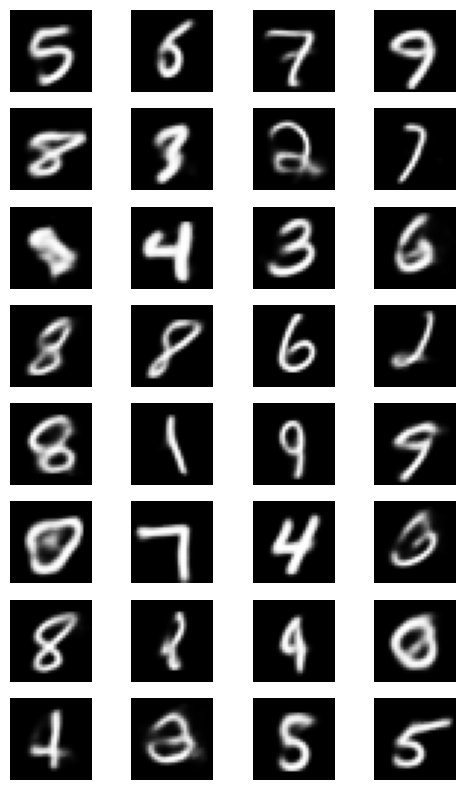

In [10]:
# 从标准正态分布采样生成图像
encoder.eval()
decoder.eval()

with torch.no_grad():
    z = torch.randn(batch_size, hidden_size).to(device)
    pred_x = torch.sigmoid(decoder(z))  # 将logits转为概率
    pred_x = pred_x.cpu()

plt.figure(figsize=(6, 10))
for i in range(batch_size):
    plt.subplot(8, 4, i+1)
    plt.imshow(pred_x[i].squeeze(0), cmap='gray')
    plt.axis('off')
plt.show()

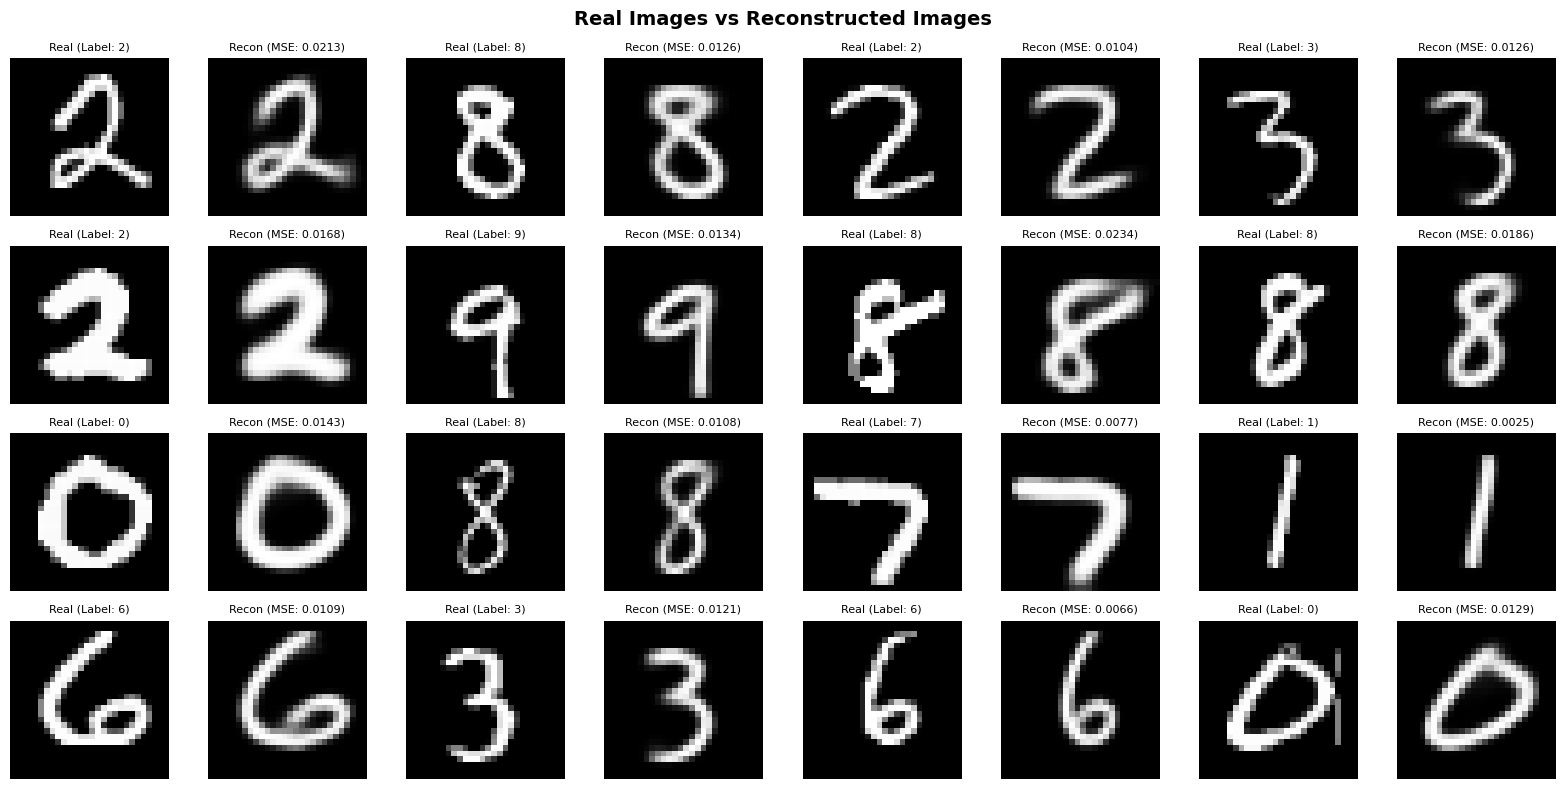

平均重构误差 (MSE): 0.012923


In [11]:
# 测试集重构对比
encoder.eval()
decoder.eval()

# 从测试集取一个batch
test_batch = next(iter(test_data))
test_images, test_labels = test_batch
test_images = test_images[:16].to(device)  # 只取16张图

with torch.no_grad():
    # 编码-解码
    mu, logvar = encoder(test_images)
    std = torch.exp(0.5 * logvar)
    epsilon = torch.randn_like(std)
    z = mu + std * epsilon
    recon_images = torch.sigmoid(decoder(z))
    
    # 计算重构误差
    mse = nn.functional.mse_loss(recon_images, test_images, reduction='none').mean(dim=[1,2,3])

test_images_cpu = test_images.cpu()
recon_images_cpu = recon_images.cpu()

# 可视化对比
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i in range(16):
    # 原图
    axes[i//4, (i%4)*2].imshow(test_images_cpu[i].squeeze(0), cmap='gray')
    axes[i//4, (i%4)*2].set_title(f'Real (Label: {test_labels[i].item()})', fontsize=8)
    axes[i//4, (i%4)*2].axis('off')
    
    # 重构图
    axes[i//4, (i%4)*2+1].imshow(recon_images_cpu[i].squeeze(0), cmap='gray')
    axes[i//4, (i%4)*2+1].set_title(f'Recon (MSE: {mse[i]:.4f})', fontsize=8)
    axes[i//4, (i%4)*2+1].axis('off')

plt.suptitle('Real Images vs Reconstructed Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"平均重构误差 (MSE): {mse.mean():.6f}")

插值: 数字2 → 数字8


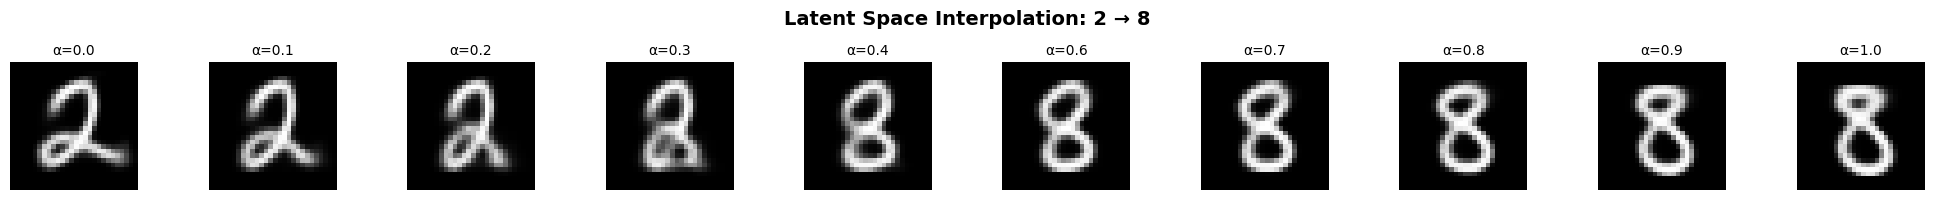

In [ ]:
# 隐空间插值 - 图像过渡
encoder.eval()
decoder.eval()

# 自动选择两张不同数字的图像
idx1 = 0
idx2 = None
for i in range(1, len(test_labels)):
    if test_labels[i] != test_labels[idx1]:
        idx2 = i
        break

if idx2 is None:
    idx2 = len(test_labels) - 1

print(f"插值: 数字{test_labels[idx1].item()} → 数字{test_labels[idx2].item()}")

img1 = test_images[idx1:idx1+1]
img2 = test_images[idx2:idx2+1]

with torch.no_grad():
    z1, _ = encoder(img1)
    z2, _ = encoder(img2)
   
    n_steps = 10
    interpolations = []
    
    for alpha in torch.linspace(0, 1, n_steps):
        z_interp = (1 - alpha) * z1 + alpha * z2
        img_interp = torch.sigmoid(decoder(z_interp))
        interpolations.append(img_interp.cpu())

# 可视化图像过渡
fig, axes = plt.subplots(1, n_steps, figsize=(20, 2))

for i, img in enumerate(interpolations):
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'α={i/(n_steps-1):.1f}', fontsize=10)
    axes[i].axis('off')

plt.suptitle(f'Latent Space Interpolation: {test_labels[idx1].item()} → {test_labels[idx2].item()}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Epoch 1/80 | β=0.0000
  Loss: 168.5286 | Recon: 168.5286 | KL: 534.9047
Epoch 11/80 | β=0.0750
  Loss: 143.3163 | Recon: 142.1975 | KL: 14.9165
Epoch 21/80 | β=0.1500
  Loss: 141.9950 | Recon: 140.1846 | KL: 12.0693
Epoch 31/80 | β=0.2250
  Loss: 141.4752 | Recon: 139.2345 | KL: 9.9590
Epoch 41/80 | β=0.3000
  Loss: 141.4784 | Recon: 138.6963 | KL: 9.2738
Epoch 51/80 | β=0.3000
  Loss: 141.0203 | Recon: 138.2054 | KL: 9.3828
Epoch 61/80 | β=0.3000
  Loss: 140.6257 | Recon: 137.8031 | KL: 9.4087
Epoch 71/80 | β=0.3000
  Loss: 140.7025 | Recon: 137.8666 | KL: 9.4530


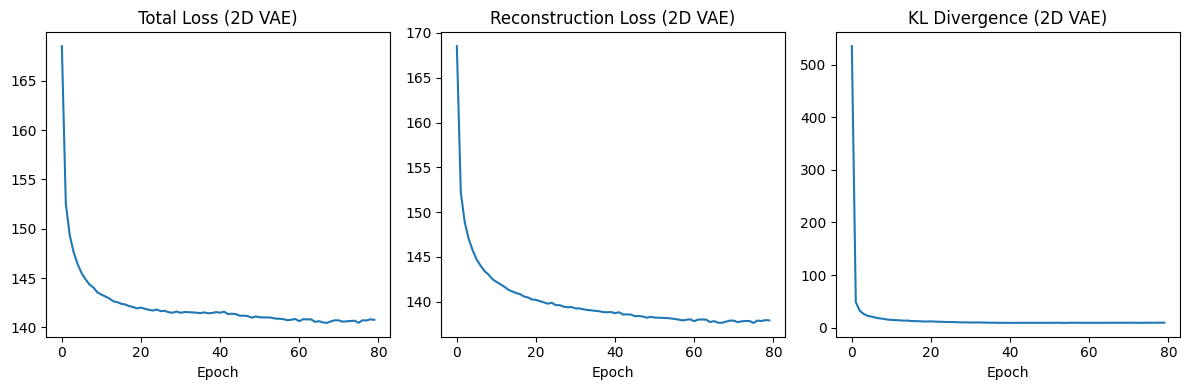


2D VAE 训练完成！


In [ ]:
# 训练2D隐空间VAE用于可视化聚类

hidden_size_2d = 2
epoch_2d = 80
lr_2d = 0.001

encoder_2d = Encoder(1, hidden_size_2d).to(device)
decoder_2d = Decoder(1, hidden_size_2d).to(device)

optim_2d = torch.optim.Adam(
    list(encoder_2d.parameters()) + list(decoder_2d.parameters()), 
    lr=lr_2d
)

# β-VAE策略
warmup_epochs_2d = 40
beta_start_2d = 0.0
beta_end_2d = 0.3 

losses_2d = []
recon_losses_2d = []
kl_losses_2d = []

for e in range(epoch_2d):
    if e < warmup_epochs_2d:
        beta = beta_start_2d + (beta_end_2d - beta_start_2d) * (e / warmup_epochs_2d)
    else:
        beta = beta_end_2d
    
    if e % 10 == 0:
        print(f"Epoch {e+1}/{epoch_2d} | β={beta:.4f}")
    
    epoch_loss = 0
    epoch_recon = 0
    epoch_kl = 0
    
    for batch_data, _ in train_data:
        current_batch_size = batch_data.shape[0]
        batch_data = batch_data.to(device)
        
        mu, logvar = encoder_2d(batch_data)
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        
        pre_x = decoder_2d(z)
        
        recon_loss = nn.functional.binary_cross_entropy_with_logits(
            pre_x, batch_data, reduction='sum'
        ) / current_batch_size
        
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / current_batch_size
        
        loss = recon_loss + beta * kl_loss
        
        optim_2d.zero_grad()
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(encoder_2d.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(decoder_2d.parameters(), max_norm=1.0)
        
        optim_2d.step()
        
        epoch_loss += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()
    
    avg_loss = epoch_loss / len(train_data)
    avg_recon = epoch_recon / len(train_data)
    avg_kl = epoch_kl / len(train_data)
    
    if e % 10 == 0:
        print(f"  Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}")
    
    losses_2d.append(avg_loss)
    recon_losses_2d.append(avg_recon)
    kl_losses_2d.append(avg_kl)

# 绘制2D VAE训练曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(losses_2d)
plt.title('Total Loss (2D VAE)')
plt.xlabel('Epoch')
plt.subplot(1, 3, 2)
plt.plot(recon_losses_2d)
plt.title('Reconstruction Loss (2D VAE)')
plt.xlabel('Epoch')
plt.subplot(1, 3, 3)
plt.plot(kl_losses_2d)
plt.title('KL Divergence (2D VAE)')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

print("\n2D VAE 训练完成！")

2D隐空间编码形状: (60000, 2)


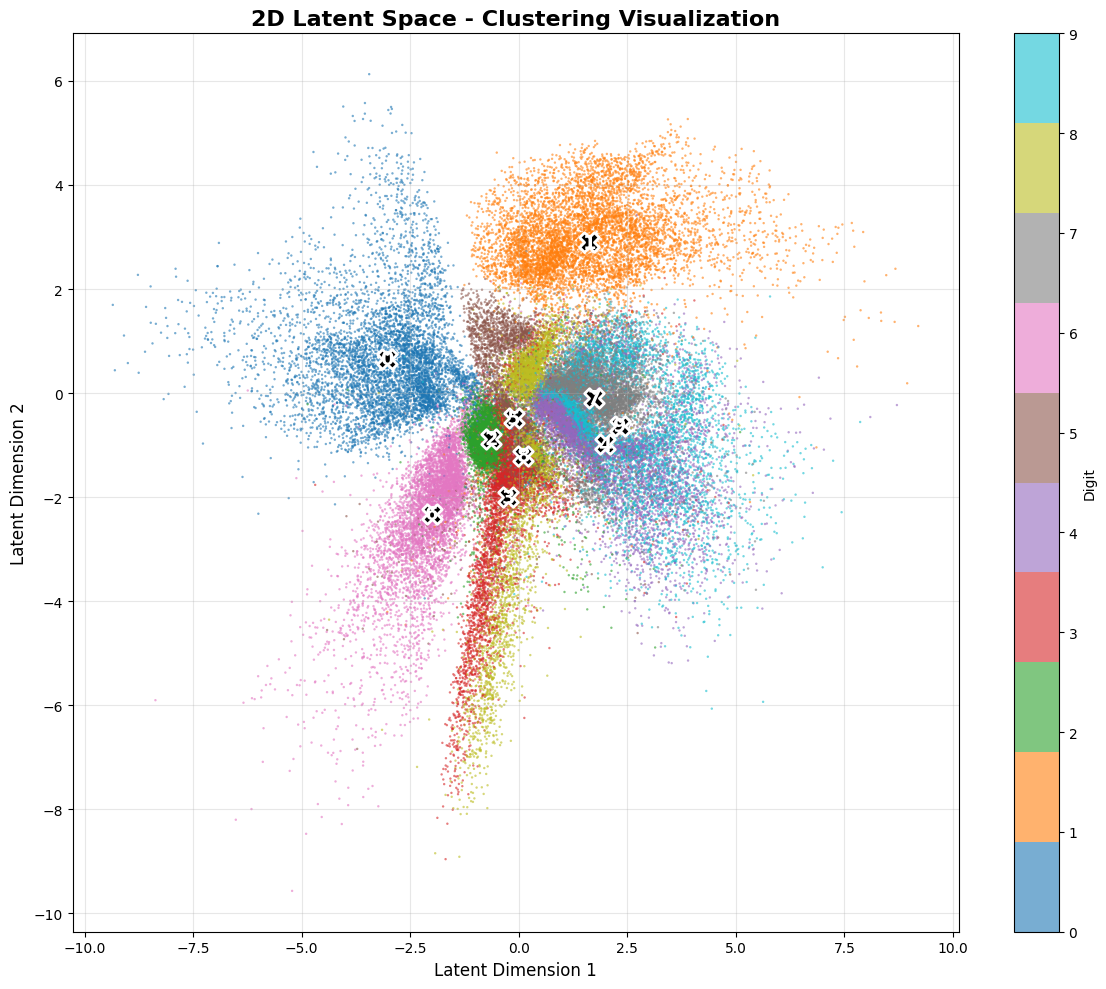


每个数字在2D空间的统计:
数字 0: 均值=(-3.033, 0.662), 标准差=(1.253, 1.075), 样本数=5923
数字 1: 均值=(1.625, 2.898), 标准差=(1.504, 0.985), 样本数=6742
数字 2: 均值=(-0.641, -0.876), 标准差=(0.484, 0.484), 样本数=5958
数字 3: 均值=(-0.244, -1.998), 标准差=(0.643, 1.540), 样本数=6131
数字 4: 均值=(1.987, -0.980), 标准差=(1.272, 0.984), 样本数=5842
数字 5: 均值=(-0.122, -0.488), 标准差=(0.610, 1.072), 样本数=5421
数字 6: 均值=(-2.007, -2.319), 标准差=(0.854, 1.224), 样本数=5918
数字 7: 均值=(1.738, -0.091), 标准差=(0.736, 0.698), 样本数=6265
数字 8: 均值=(0.101, -1.208), 标准差=(0.541, 2.043), 样本数=5851
数字 9: 均值=(2.329, -0.628), 标准差=(1.250, 1.115), 样本数=5949


In [ ]:
# 聚类效果
encoder_2d.eval()

all_z = []
all_labels = []

with torch.no_grad():
    for x, y in train_data:
        x = x.to(device)
        mu, _ = encoder_2d(x)
        all_z.append(mu.cpu())
        all_labels.append(y)

z_2d = torch.cat(all_z, dim=0).numpy()
labels = torch.cat(all_labels, dim=0).numpy()

print(f"2D隐空间编码形状: {z_2d.shape}")

# 绘制
plt.figure(figsize=(12, 10))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10', 
                     s=3, alpha=0.6, edgecolors='none')
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.title('2D Latent Space - Clustering Visualization', fontsize=16, fontweight='bold')
plt.xlabel('Latent Dimension 1', fontsize=12)
plt.ylabel('Latent Dimension 2', fontsize=12)
plt.grid(alpha=0.3)

# 添加每个数字的中心点标记
for digit in range(10):
    mask = labels == digit
    center_x = z_2d[mask, 0].mean()
    center_y = z_2d[mask, 1].mean()
    plt.scatter(center_x, center_y, c='black', s=200, marker='X', 
               edgecolors='white', linewidths=2, zorder=5)
    plt.text(center_x, center_y, str(digit), fontsize=14, fontweight='bold',
            ha='center', va='center', color='white', zorder=6)

plt.tight_layout()
plt.show()

# 统计每个数字的分布
print("\n每个数字在2D空间的统计:")
for digit in range(10):
    mask = labels == digit
    digit_z = z_2d[mask]
    print(f"数字 {digit}: 均值=({digit_z[:, 0].mean():.3f}, {digit_z[:, 1].mean():.3f}), "
          f"标准差=({digit_z[:, 0].std():.3f}, {digit_z[:, 1].std():.3f}), "
          f"样本数={mask.sum()}")

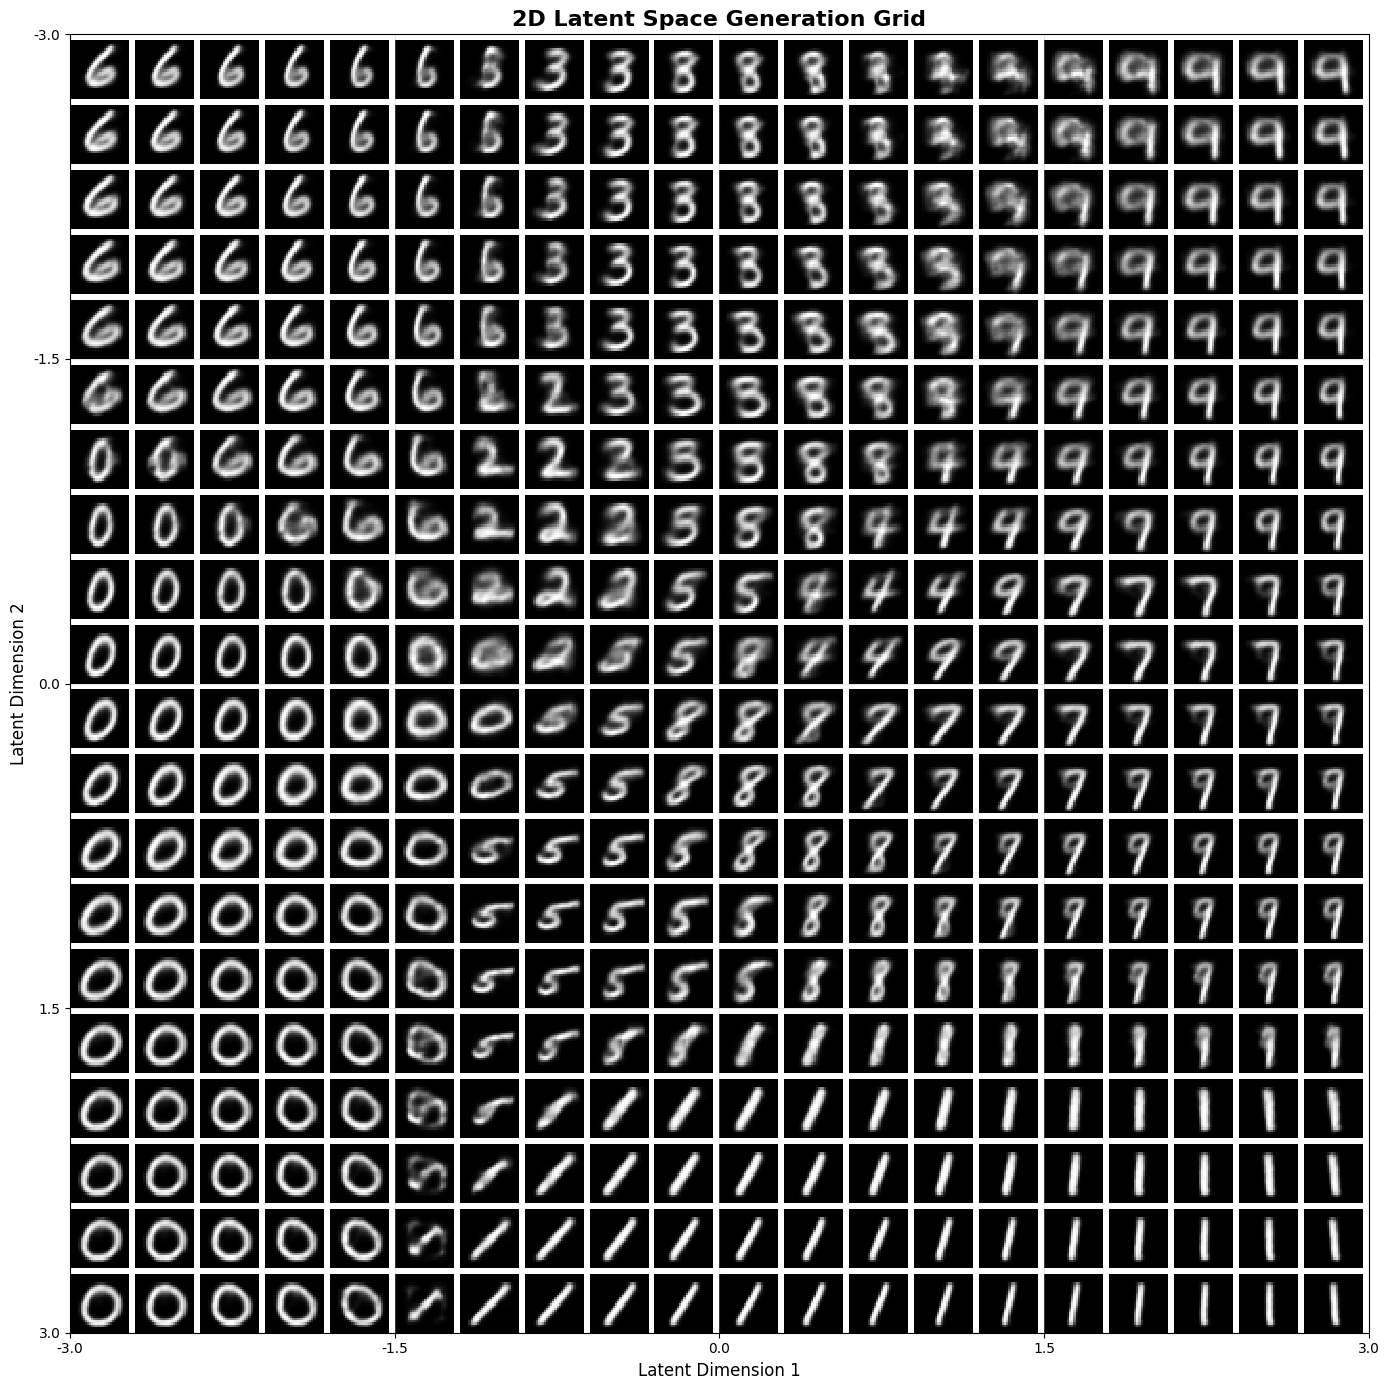

In [17]:
# 从2D隐空间的网格采样生成图像
encoder_2d.eval()
decoder_2d.eval()

# 定义2D网格
n_grid = 20
x_range = np.linspace(-3, 3, n_grid)
y_range = np.linspace(-3, 3, n_grid)

# 生成网格图像
fig, ax = plt.subplots(figsize=(14, 14))

for i, y_val in enumerate(reversed(y_range)):
    for j, x_val in enumerate(x_range):
        z = torch.tensor([[x_val, y_val]], dtype=torch.float32).to(device)
        
        with torch.no_grad():
            img = torch.sigmoid(decoder_2d(z))
            img = img.cpu().squeeze().numpy()
        
        ax.imshow(img, cmap='gray', 
                 extent=[j, j+0.9, i, i+0.9],
                 interpolation='nearest')

ax.set_xlim(0, n_grid)
ax.set_ylim(0, n_grid)
ax.set_xticks(np.arange(0, n_grid+1, 5))
ax.set_yticks(np.arange(0, n_grid+1, 5))
ax.set_xticklabels([f'{v:.1f}' for v in np.linspace(-3, 3, 5)])
ax.set_yticklabels([f'{v:.1f}' for v in np.linspace(3, -3, 5)])
ax.set_xlabel('Latent Dimension 1', fontsize=12)
ax.set_ylabel('Latent Dimension 2', fontsize=12)
ax.set_title('2D Latent Space Generation Grid', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()